## Neural Machine Translation.

We will build a `Neural Machine Translation (NMT)` model to translate human readable dates ("25th of June, 2009") into machine readable dates ("2009-06-25"). We will do this using an attention model, one of the most sophisticated sequence to sequence models.

In [1]:
from keras.layers import Bidirectional, Concatenate, Permute, Dot, Input, LSTM, Multiply
from keras.layers import RepeatVector, Dense, Activation, Lambda
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.models import load_model, Model
import keras.backend as K
import numpy as np

from faker import Faker
import random
from tqdm import tqdm
from babel.dates import format_date
from nmt_utils import *
import matplotlib.pyplot as plt
%matplotlib inline

## Translating human readable dates into machine readable dates.
The model you will build here could be used to translate from one language to another, such as translating from English to Hindi. However, language translation requires massive datasets and usually takes days of training on GPUs. To give you a place to experiment with these models even without using massive datasets, we will instead use a simpler "date translation" task.

The network will input a date written in a variety of possible formats (e.g. "the 29th of August 1958", "03/30/1968", "24 JUNE 1987") and translate them into standardized, machine readable dates (e.g. "1958-08-29", "1968-03-30", "1987-06-24"). We will have the network learn to output dates in the common machine-readable format YYYY-MM-DD.


### Dataset
We will train the model on a dataset of 10000 human readable dates and their equivalent, standardized, machine readable dates. Let's run the following cells to load the dataset and print some examples.

In [2]:
m = 10000
dataset, human_vocab, machine_vocab, inv_machine_vocab =  load_dataset(m)

In [3]:
dataset[:10]

[('Monday, May 10, 1993', '1993-05-10'),
 ('7/28/70', '1970-07-28'),
 ('April 5, 2016', '2016-04-05'),
 ('September 28, 1986', '1986-09-28'),
 ('Aug 27, 1990', '1990-08-27'),
 ('November 9, 1980', '1980-11-09'),
 ('Monday, September 24, 2001', '2001-09-24'),
 ('Jan 24, 1979', '1979-01-24'),
 ('December 19, 1976', '1976-12-19'),
 ('4/9/94', '1994-04-09')]

We've loaded:
* `dataset`: a list of tuples of (human readable date, machine redable date)
* `human_vocab`: a python dictionary mapping all characters used in the human readable dates to an integer-valued index
* `machine_vocab`: a python dictionary mapping all characters used in machine readable dates to an integer-valued index. These indices are not necessarily consistent with human_vocab.
* `inv_machine_vocab`: the inverse dictionary of machine_vocab, mapping from indices back to characters.

Let's preprocess the data and map the raw text data into the index values. We will also use Tx=30 (which we assume is the maximum length of the human readable date; if we get a longer input, we would have to truncate it) and Ty=10 (since "YYYY-MM-DD" is 10 characters long).


In [4]:
Tx = 30
Ty = 10
X, Y , Xoh, Yoh = preprocess_data(dataset, human_vocab, machine_vocab, Tx, Ty)

print("X.shape:", X.shape)
print("Y.shape:",  Y.shape)
print("Xoh.shape:", Xoh.shape)
print("Yoh.shape:", Yoh.shape)

X.shape: (10000, 30)
Y.shape: (10000, 10)
Xoh.shape: (10000, 30, 42)
Yoh.shape: (10000, 10, 11)


* X: a processed version of the human readable dates in the training set, where each character is replaced by an index mapped to the character via human_vocab. Each date is further padded to $T \perp$
values with a special character (< pad >). X.shape = (m, Tx).
* Y: a processed version of the machine readable dates in the training set, where each character is replaced by the index it is mapped to in `machine_vocab`. You should have `Y.shape = (m, Ty).`
* `Xoh`: one-hot version of `X`, the "1" entry's index is mapped to the character thanks to `human_vocab`. `Xoh.shape = (m, Tx, len(human_vocab))`
* Yoh: one-hot version of `Y`, the "1" entry's index is mapped to the character thanks to `machine_vocab`. `Yoh.shape = (m, Tx, len(machine_vocab))`. Here, `len(machine_vocab) = 11 `since there are 11 characters ('-' as well as 0-9).



Lets also look at some examples of preprocessed training examples. Feel free to play with index in the cell below to navigate the dataset and see how source/target dates are preprocessed.


In [5]:
index = 0
print("Source date: ", dataset[index][0])
print("Target data:", dataset[index][1])
print()
print("Source after preprocessing (indices):", X[index])
print("Target after preprocessing (indices):", Y[index])
print()
print("Source after preprocessing (one-hot):", Xoh[index])
print("Target after preprocessing (one-hot):", Yoh[index])


Source date:  Monday, May 10, 1993
Target data: 1993-05-10

Source after preprocessing (indices): [32 34 33 26 23 41  1  0 32 23 41  0  4  3  1  0  4 12 12  6  0  0  0  0
  0  0  0  0  0  0]
Target after preprocessing (indices): [ 2 10 10  4  0  1  6  0  2  1]

Source after preprocessing (one-hot): [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
Target after preprocessing (one-hot): [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


# Neural Machine Translation with Attention.

If you had to translate a book's paragraph from French to English, you would not read the whole paragraph, then close the book and translate. Even during the translation process, you would read/re-read and focus on the parts of the French paragraph corresponding to the parts of the English you are writing down.
The attention mechanism tells a Neural Machine Translation model where it should pay attention to at any step.


## Attention Mechanism.


In this part, we will implement the attention mechanism presented in the lecture videos. Here is a figure to remind us how the model works. The diagram on the left shows the attention model. The diagram on the right shows what one "Attention" step does to calculate the attention variables $α^{<t, t'>}$,  which are used to compute the context variable $context^{(t)}$
for each timestep in the output (t = 1, ...$T_y$).




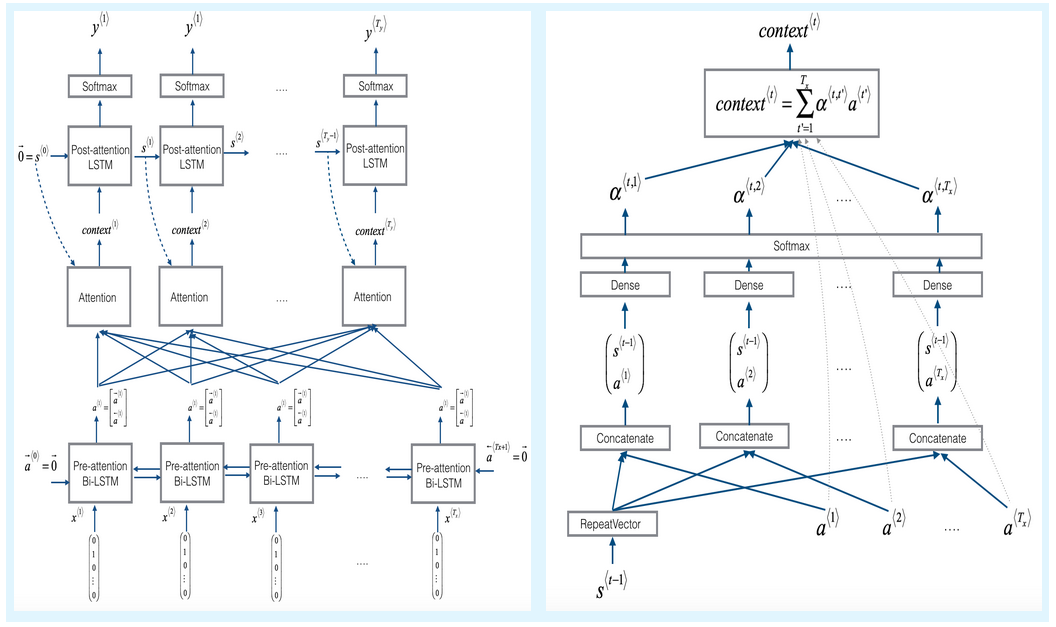

 **Figure 1**: Neural machine translation with attention.

 Here are some properties of the model:
 * There are two separate LSTMs in this model (see diagram on the left). Because the one at the bottom of the picture is a Bi-directional LSTM and comes before the attention mechanism, we will call it pre-attention Bi-LSTM. The LSTM at the top of the diagram comes after the attention mechanism, so we will call it the post-attention LSTM. The pre-attention Bi-LSTM goes through $T_x$
time steps; the post-attention LSTM goes through $T_y$
time steps.

* The post-attention LSTM passes $s^{<t>}, c^{<t>}$
from one time step to the next.
.Since we are using an LSTM here, the LSTM has both the output activation  $s^{<t>}$
and the hidden cell state $ $s^{<t>}$
. However, unlike previous text generation examples (such as Dinosaurus), in this model the post-activation LSTM at time  t, does will not take the specific generated  $y^{<t-1>}
as input; it only takes  $s^{<t>}
and   $c^{<t>}$
as input. We have designed the model this way, because (unlike language generation where adjacent characters are highly correlated) there isn't as strong a dependency between the previous character and the next character in a YYYY-MM-DD date.

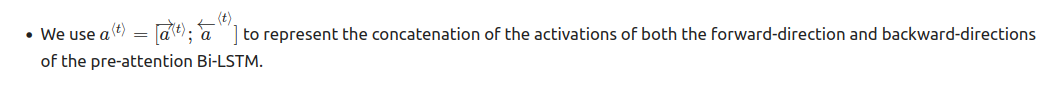

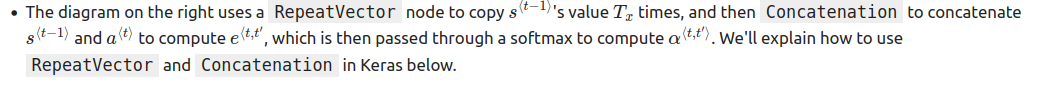

Lets implement this model. You will start by implementing two functions: `one_step_attention() and model().`

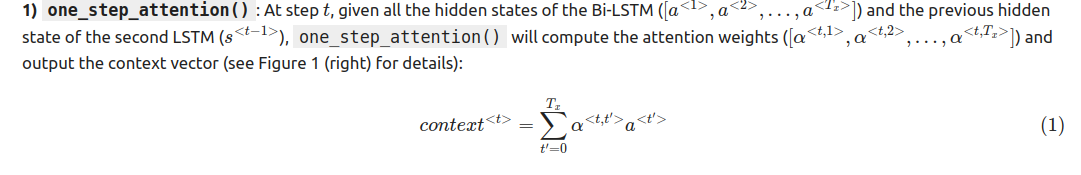

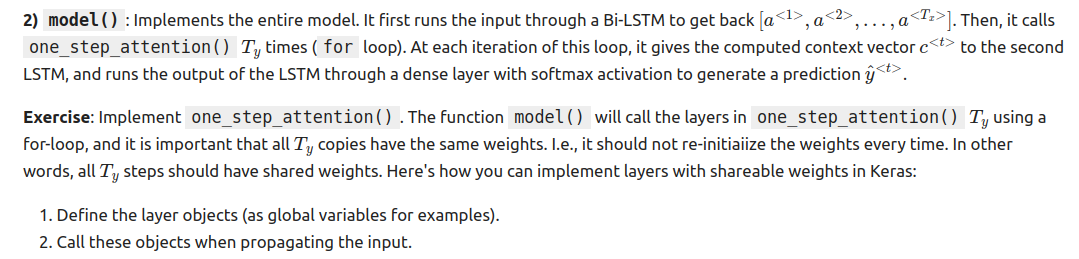

In [6]:
import tensorflow as tf

def softmax(z):
    z = z - tf.reduce_max(z, axis=-1, keepdims=True)  # numerical stability
    exp_z = tf.exp(z)
    return exp_z / tf.reduce_sum(exp_z, axis=-1, keepdims=True)


In [7]:
# defined shared layers as the global variables.
repeator = RepeatVector(Tx)
concatenator = Concatenate(axis=-1)
densor = Dense(1, activation = "relu")
activator = Activation(softmax, name='attention_weights') # We are using a custom softmax(axis = 1) loaded in this notebook
dotor = Dot(axes = 1)



Now we can use these layers to implement one_step_attention(). In order to propagate a Keras tensor object X through one of these layers, use `layer(X)` (or `layer([X,Y])` if it requires multiple inputs.), e.g. `densor(X)` will propagate X through the `Dense(1)` layer defined above.


In [8]:
def one_step_attention(a, s_prev):
  """
  Performs one step of attention: Outputs a context vector computed as a dot product of the attention weights
  "alphas" and the hidden states "a" of the Bi-LSTM.

  Arguments:
  a -- hidden state output of the Bi-LSTM, numpy-array of shape (m, Tx, 2*n_a)
  s_prev -- previous hidden state of the (post-attention) LSTM, numpy-array of shape (m, n_s)

  Returns:
  context -- context vector, input of the next (post-attetion) LSTM cell
  """
  # Use repeator to repeat s_prev to be of shape (m, Tx, n_s) so that you can concatenate it with all hidden states "a".

  s_prev = repeator(s_prev)

  # Use concatenator to concatenate a and s_prev on the last axis.
  concat = concatenator([a, s_prev])

  # Use densor to propagate concat through a small fully-connected neural network to compute the "energies" variable e.
  e = densor(concat)

  # Use activator and e to compute the attention weights "alphas".
  alphas = activator(e)
  # Use dotor together with "alphas" and "a" to compute the context vector to be given to the next (post-attention) LSTM-cell.
  context = dotor([alphas, a])

  return context







We'll be able to check the output of the `one_step_attention()` after we've coded the `model()` function.


Here we implement `model()` as explained in figure 2 and the text above. Again, we have defined global layers that will share weights to be used in model().

In [9]:
n_a = 64
n_s = 128
post_activation_LSTM = LSTM(n_s, return_state=True)
output_layer = Dense(len(machine_vocab), activation=softmax)


Now you can use these layers $T_y$
times in a for loop to generate the outputs, and their parameters will not be reinitialized. You will have to carry out the following steps:
1. Propagate the input to a Bidirectional LSTM
2. Iterate for t = 0, ..., $T_y - 1$

  A. Call one_step_attention() on [$α^{<t,1>}, $α^{<t,2>},$α^{<t,3>},..,$α^{<t,$T_x$>] and  $s^{<t>}$ to get the context vector
 $context^{<t>}$.
  
  B. Give  $context^{<t>}$ to the post-attention LSTM cell. Remember pass in the previous hidden-state $s^{<t-1>}$ and cell-states $c^{<t>}$ of this LSTM using initial_state= `[previous hidden state, previous cell state]`. Get back the new hidden state $s^{<t>}$  and the new cell state $c^{<t>}$ .

  C. Apply a softmax layer to, $s^{<t>}$ get the output.
  D. Save the output by adding it to the list of outputs.

3.   Create your Keras model instance, it should have three inputs ("inputs", $s^{<0>}$, and $c^{<0>}$ )and output the list of "outputs".



In [10]:
from tensorflow.keras.layers import LSTM

def post_activation_LSTM_cell(context, initial_state, n_s):
    """
    Arguments:
    context -- the context vector from attention mechanism, shape (batch_size, 1, features)
    initial_state -- list of previous [s, c], each of shape (batch_size, n_s)
    n_s -- hidden state size of the LSTM

    Returns:
    s_next -- next hidden state
    cache -- placeholder (None)
    c_next -- next cell state
    """

    s_prev, c_prev = initial_state  # unpack previous states

    # Correct: pass units=n_s
    lstm = LSTM(units=n_s, return_state=True)

    # Keras expects input of shape (batch_size, time_steps, features)
    # context should be reshaped if needed
    s_next, c_next = lstm(context, initial_state=[s_prev, c_prev])[:2]

    cache = None  # for compatibility

    return s_next, cache, c_next


In [11]:
from tensorflow.keras.models import Model as KModel  # rename Keras Model to avoid conflict

def Model(Tx, Ty, n_a, n_s, human_vocab_size, machine_vocab_size):
    """
    Arguments:
    Tx -- length of the input sequence
    Ty -- length of the output sequence
    n_a -- hidden state size of the Bi-LSTM
    n_s -- hidden state size of the post-attention LSTM
    human_vocab_size -- size of the python dictionary "human_vocab"
    machine_vocab_size -- size of the python dictionary "machine_vocab"

    Returns:
    model -- Keras model instance
    """
    # Inputs
    X = Input(shape=(Tx, human_vocab_size))
    s0 = Input(shape=(n_s,), name='s0')
    c0 = Input(shape=(n_s,), name='c0')
    s = s0
    c = c0

    outputs = []

    # Pre-attention Bi-LSTM
    a = Bidirectional(LSTM(n_a, return_sequences=True))(X)

    # Decoder loop
    for t in range(Ty):
        context = one_step_attention(a, s)
        s, _, c = post_activation_LSTM_cell(context, initial_state=[s, c], n_s=n_s)
        out = output_layer(s)
        outputs.append(out)

    # Create Keras model
    model = KModel(inputs=[X, s0, c0], outputs=outputs)

    return model


In [12]:
import tensorflow as tf

from tensorflow.keras.layers import LSTMCell, RNN, Dense


In [13]:
model = Model(Tx, Ty, n_a, n_s, len(human_vocab), len(machine_vocab))

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 42)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s0 (InputLayer)     │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 128)   │     54,784 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 30, 128)   │          0 │ s0[0][0],         │
│ (RepeatVector)      │                   │            │ lstm_2[0][0],     │
│                     │                   │            │ lstm_3[0][0],     │
│                     │                   │            │ lstm_4[0][0],     │
│                     │                   │            │ lstm_5[0][0],     │
│                     │                   │            │ lstm_6[0][0],     │
│                     │                   │            │ lstm_7[0][0],     │
│                     │                   │            │ lstm_8[0][0],     │
│                     │                   │            │ lstm_9[0][0],     │
│                     │                   │            │ lstm_10[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 30, 256)   │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[1]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[2]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[3]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[4]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[5]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[6]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[7]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[8]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[9]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │        257 │ concatenate[0][0… │
│                     │                   │            │ concatenate[1][0… │
│                     │                   │            │ concatenate[2][0… │
│                     │                   │            │ concatenate[3][0… │
│                     │                   │            │ concatenate[4][0… │
│                     │                   │            │ concatenate[5][0… │
│                     │                   │            │ concatenate[6][0… │
│                     │                   │            │ concatenate[7][0… │
│                     │                   │            │ concatenate[8][0

 Total params: 1,372,300 (5.23 MB)

 Trainable params: 1,372,300 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

As usual, after creating your model in Keras, you need to compile it and define what loss, optimizer and metrics your are want to use. Compile your model using categorical_crossentropy loss, a custom Adam optimizer (learning rate = 0.005, $β_1$ = 0.9,  $β_2$ = 0.999, `decay` = 0.01) and `[accuracy`] metrics:



In [15]:
opt = Adam(learning_rate = 0.005, beta_1=0.9, beta_2=0.999)

# For Ty outputs
# Ty = len(outputs)  # or whatever your decoder steps are

losses = ['categorical_crossentropy'] * Ty
metrics = ['accuracy'] * Ty

model.compile(loss=losses, optimizer=opt, metrics=metrics)

# model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])


The last step is to define all our inputs and outputs to fit the model:

* We already have X of shape (m = 10000, Tx = 30)
containing the training examples.
* We need to create `s0` and `c0` to initialize your `post_activation_LSTM_cell` with 0s.
* Given the model() we coded, we need the "outputs" to be a list of 11 elements of shape (m, T_y). So that: `outputs[i][0], ..., outputs[i][Ty]` represent the true labels (characters) corresponding to the $i^{th}$
training example (X[i]). More generally, outputs[i][j] is the true label of the  $j^{th}$ character in the  $i^{th}$
training example.

In [16]:
s0 = np.zeros((m, n_s))
c0 = np.zeros((m, n_s))
outputs = list(Yoh.swapaxes(0,1))

In [17]:
model.fit([Xoh, s0, c0], outputs, epochs=1, batch_size=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 146ms/step - dense_1_accuracy: 0.7480 - dense_1_accuracy_1: 0.7405 - dense_1_accuracy_2: 0.3777 - dense_1_accuracy_3: 0.1770 - dense_1_accuracy_4: 0.9861 - dense_1_accuracy_5: 0.7597 - dense_1_accuracy_6: 0.2615 - dense_1_accuracy_7: 0.9485 - dense_1_accuracy_8: 0.3964 - dense_1_accuracy_9: 0.1795 - dense_1_loss: 2.2070 - loss: 11.2272


While training you can see the loss as well as the accuracy on each of the 10 positions of the output. The table below gives you an example of what the accuracies could be if the batch had 2 examples:

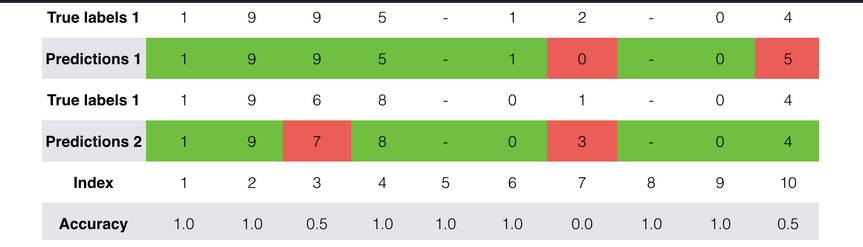

Thus, `dense_2_acc_8: 0.89` means that you are predicting the 7th character of the output correctly 89% of the time in the current batch of data.

We have run this model for longer, and saved the weights. Run the next cell to load our weights. (By training a model for several minutes, you should be able to obtain a model of similar accuracy, but loading our model will save you time.)

In [18]:
import os

# Create 'models' folder if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')


In [19]:
model.save_weights('models/model.weights.h5')


In [20]:
model.load_weights('models/model.weights.h5')


In [21]:
import numpy as np
from tensorflow.keras.utils import to_categorical

def string_to_int(string, Tx, human_vocab):
    """
    Converts a string into a list of integers using human_vocab.

    Arguments:
    string -- input string (e.g., '3 May 1979')
    Tx -- max input length (padding/truncation)
    human_vocab -- dictionary mapping characters to integers

    Returns:
    source -- list of integers of length Tx
    """

    # Convert string to lowercase (optional)
    string = string.lower()

    # Initialize list
    source = []

    # Convert each character to its index
    for char in string:
        if char in human_vocab:
            source.append(human_vocab[char])
        else:
            # Use the index of a special token for unknown chars (like ' ')
            source.append(human_vocab[' '])

    # Pad with zeros or truncate to fit Tx
    if len(source) < Tx:
        source += [human_vocab[' ']] * (Tx - len(source))
    else:
        source = source[:Tx]

    return source


In [23]:
EXAMPLES = [
    '3 May 1979',
    '5 April 09',
    '21th of August 2016',
    'Tue 10 Jul 2007',
    'Saturday May 9 2018',
    'March 3 2001',
    'March 3rd 2001',
    '1 March 2001'
]

for example in EXAMPLES:

    # Convert input sentence to integers
    source = string_to_int(example, Tx, human_vocab)

    # One-hot encode
    source = np.array([
        to_categorical(x, num_classes=len(human_vocab))
        for x in source
    ])

    # Add batch dimension
    source = np.expand_dims(source, axis=0)
    # shape: (1, Tx, human_vocab_size)

    # INITIAL STATES FOR *ONE* SAMPLE
    s0_inf = np.zeros((1, n_s))
    c0_inf = np.zeros((1, n_s))

    # Predict
    prediction = model.predict([source, s0_inf, c0_inf], verbose=0)

    # Convert predictions to characters
    prediction = np.argmax(prediction, axis=-1)
    output = ''.join(inv_machine_vocab[int(i)] for i in prediction)

    print("source:", example)
    print("output:", output)


/tmp/ipython-input-683044852.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output = ''.join(inv_machine_vocab[int(i)] for i in prediction)


source: 3 May 1979
output: 1999-05-03
source: 5 April 09
output: 2000-04-04
source: 21th of August 2016
output: 2016-08-26
source: Tue 10 Jul 2007
output: 2007-08-10
source: Saturday May 9 2018
output: 2088-05-08
source: March 3 2001
output: 2010-03-00
source: March 3rd 2001
output: 2010-03-00
source: 1 March 2001
output: 2010-03-00


We can also change these examples to test with our own examples.
* Next we look closer at what attention mechanism is doing i.e. what part of the input the network paying attention to when geneating a particular output character.

## Visualizing Attention

Since the problem has a fixed output length of 10, it is also possible to carry out this task using 10 different softmax units to generate the 10 characters of the output. But one advantage of the attention model is that each part of the output (say the month) knows it needs to depend only on a small part of the input (the characters in the input giving the month). We can visualize what part of the output is looking at what part of the input.

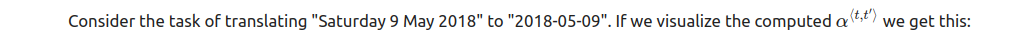

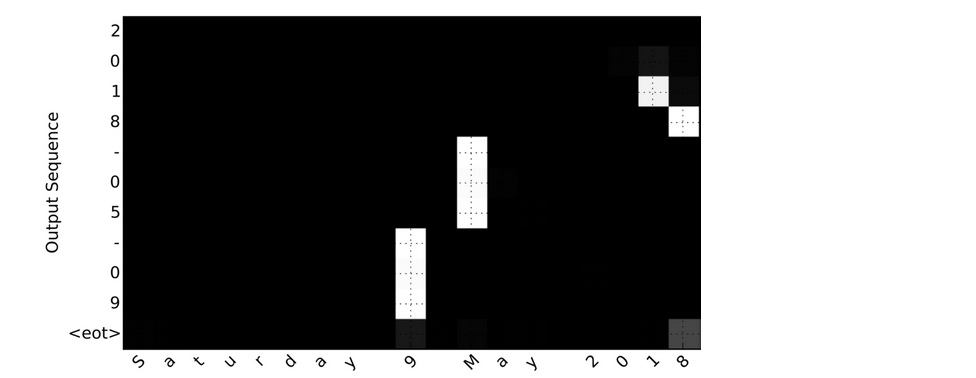

 **Figure 8**: Full Attention Map

 Notice how the output ignores the "Saturday" portion of the input. None of the output timesteps are paying much attention to that portion of the input. We see also that 9 has been translated as 09 and May has been correctly translated into 05, with the output paying attention to the parts of the input it needs to to make the translation. The year mostly requires it to pay attention to the input's "18" in order to generate "2018."

 ###  Getting the activations from the network
Lets now visualize the attention values in your network. We'll propagate an example through the network, then visualize the values of $α^{<t,t'>}$


In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 42)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s0 (InputLayer)     │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 128)   │     54,784 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 30, 128)   │          0 │ s0[0][0],         │
│ (RepeatVector)      │                   │            │ lstm_2[0][0],     │
│                     │                   │            │ lstm_3[0][0],     │
│                     │                   │            │ lstm_4[0][0],     │
│                     │                   │            │ lstm_5[0][0],     │
│                     │                   │            │ lstm_6[0][0],     │
│                     │                   │            │ lstm_7[0][0],     │
│                     │                   │            │ lstm_8[0][0],     │
│                     │                   │            │ lstm_9[0][0],     │
│                     │                   │            │ lstm_10[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 30, 256)   │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[1]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[2]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[3]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[4]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[5]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[6]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[7]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[8]… │
│                     │                   │            │ bidirectional[0]… │
│                     │                   │            │ repeat_vector[9]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │        257 │ concatenate[0][0… │
│                     │                   │            │ concatenate[1][0… │
│                     │                   │            │ concatenate[2][0… │
│                     │                   │            │ concatenate[3][0… │
│                     │                   │            │ concatenate[4][0… │
│                     │                   │            │ concatenate[5][0… │
│                     │                   │            │ concatenate[6][0… │
│                     │                   │            │ concatenate[7][0… │
│                     │                   │            │ concatenate[8][0

 Total params: 4,116,902 (15.70 MB)

 Trainable params: 1,372,300 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,744,602 (10.47 MB)

Lets now visualize the attention values in your network. We'll propagate an example through the network, then visualize the values of


The function `attention_map()` pulls out the attention values from your model and plots them.

In [ ]:
plot_attention_map(model, human_vocab, inv_machine_vocab,
                   "Tuesday April 08 1993", num=6, n_s=128)


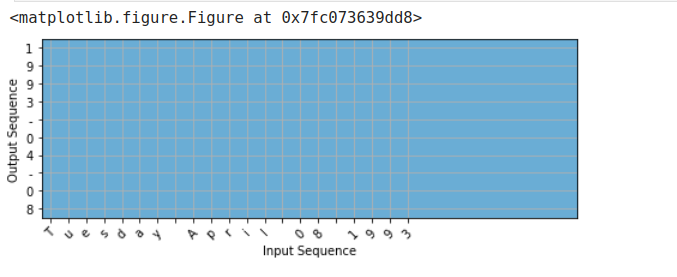

Notes:
* Machine translation models can be used to map from one sequence to another. They are useful not just for translating human languages (like French->English) but also for tasks like date format translation.
* An attention mechanism allows a network to focus on the most relevant parts of the input when producing a specific part of the output.
* A network using an attention mechanism can translate from inputs of length $T_x$ to outputs of lengths $T_y$ where $T_x$ and $T_y$ can be different.

* We can visualize attention weights $\alpha^{<t, t'>}$ to see what the network is paying attention to while generating each output.
